In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("/content/netflixcsv.zip")

In [4]:
print(df.head())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [8]:
df = df.drop_duplicates()

In [9]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


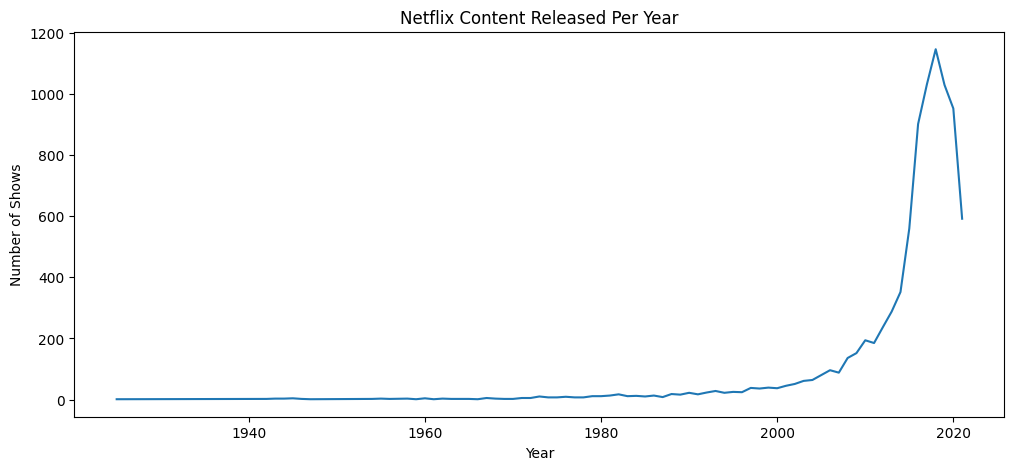

In [10]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(year_counts.index, year_counts.values)

plt.title("Netflix Content Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Shows")

plt.show()

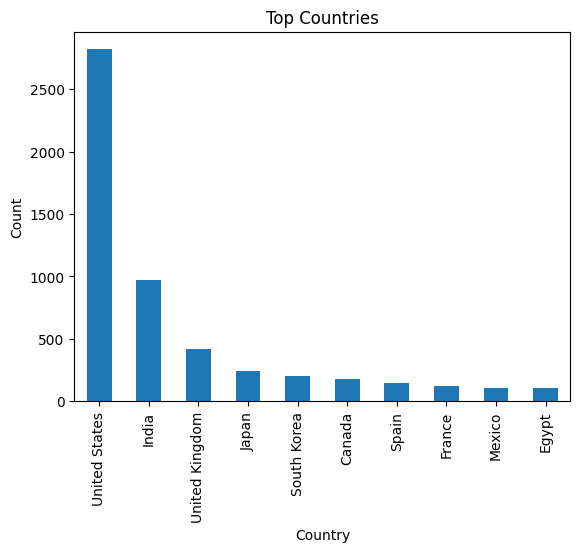

In [11]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

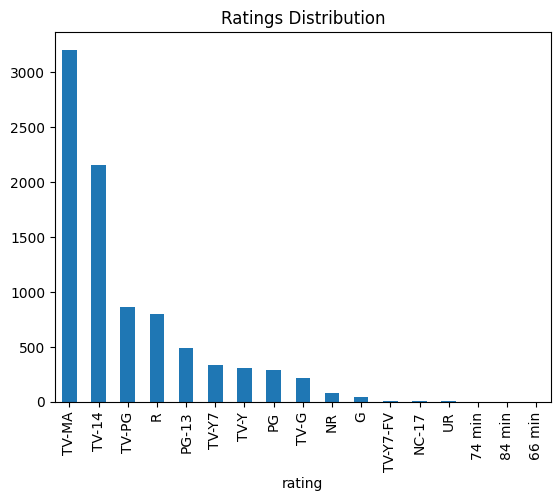

In [12]:
df['rating'].value_counts().plot(kind='bar')

plt.title("Ratings Distribution")
plt.show()

In [13]:
years = np.array(df['release_year'])

In [14]:
print(np.mean(years))


2014.1801975701146


In [15]:
print(np.max(years))

2021


In [16]:
print(np.min(years))

1925


In [17]:
le = LabelEncoder()

df['type_encoded'] = le.fit_transform(df['type'])

In [19]:
df['rating_encoded'] = LabelEncoder().fit_transform(df['rating'])
X = df[['release_year', 'rating_encoded']]
y = df['type_encoded']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7162315550510783


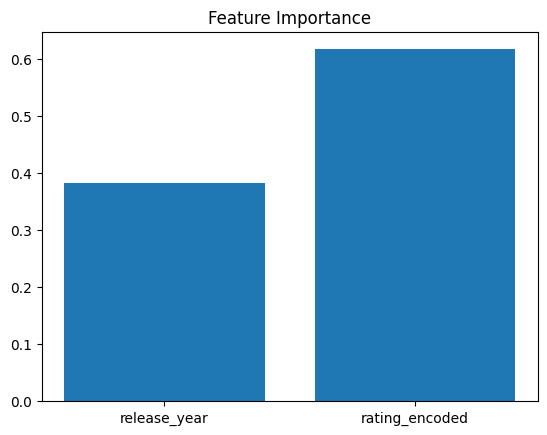

In [24]:
importance = model.feature_importances_

features = X.columns

plt.bar(features, importance)

plt.title("Feature Importance")
plt.show()

In [26]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [27]:
from collections import Counter

actors = ",".join(df['cast'].dropna()).split(",")

top_actors = Counter(actors).most_common(10)

print(top_actors)

[(' Anupam Kher', 39), (' Rupa Bhimani', 31), (' Takahiro Sakurai', 30), (' Julie Tejwani', 28), (' Om Puri', 27), (' Rajesh Kava', 26), ('Shah Rukh Khan', 26), (' Andrea Libman', 25), (' Yuki Kaji', 25), (' Boman Irani', 25)]
